# 파이토치 기초

## 파이토치 기초 문법

### 텐서 다루기

#### 텐서 생성 및 변환

In [74]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import torch

print(torch.tensor([[1, 2], [3, 4]]))
print(torch.tensor([[1, 2], [3, 4]], device="cuda:0"))
print(torch.tensor([[1, 2], [3, 4]], dtype=torch.float64))

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [2]:
temp = torch.tensor([[1, 2], [3, 4]])
print(temp.numpy())

[[1 2]
 [3 4]]


In [3]:
temp = torch.tensor([[1, 2], [3, 4]], device="cuda:0")
print(temp.to("cpu").numpy())

[[1 2]
 [3 4]]


#### 텐서의 인덱스 조작

In [6]:
temp = torch.FloatTensor([1, 2, 3, 4, 5, 6, 7]) # 1차원 텐서
print(temp[0], temp[1], temp[-1]) # 인덱스 접근
print('----------------------------------------')
print(temp[2:5], temp[4:-1]) # 슬라이스 접근

tensor(1.) tensor(2.) tensor(7.)
----------------------------------------
tensor([3., 4., 5.]) tensor([5., 6.])


#### 텐서 연산 및 차원 조작

In [8]:
v = torch.tensor([1, 2, 3])
w = torch.tensor([3, 4, 6])
print(w - v) # 길이가 같은 벡터 간 뺄셈 연산

tensor([2, 2, 3])


In [10]:
temp = torch.tensor([[1, 2], [3, 4]])

print(temp.shape)
print('----------------------------------------')
print(temp.view(4, 1)) # 2 x 2 행렬을 4 x 1로 변형
print('----------------------------------------')
print(temp.view(-1)) # 2 x 2 행렬을 1차원 벡터로 변형
print('----------------------------------------')
print(temp.view(1, -1)) # -1은 (1, ?)와 같은 의미, temp의 원소 개수는 유지하되 (1, ?) 형태여야 하므로 (1, 4)가 됨

torch.Size([2, 2])
----------------------------------------
tensor([[1],
        [2],
        [3],
        [4]])
----------------------------------------
tensor([1, 2, 3, 4])
----------------------------------------
tensor([[1, 2, 3, 4]])


### 데이터 준비

#### 단순하게 파일 불러와서 사용

In [ ]:
import pandas as pd
import torch
data = pd.read_csv("../class2.csv")

#### 커스텀 데이터셋을 만들어서 사용

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class CustomDataset(Dataset):
    def __init__(self, csv_file): # csv_file로 데이터셋 불러오기
        self.label = pd.read_csv(csv_file)

    def __len__(self): # 전체 데이터셋의 크기 반환
        return len(self.label)

    def __getitem__(self, idx): # 전체 x와 y 데이터 중에 해당 idx번째의 데이터를 가져옴
        sample = torch.tensor(self.label.iloc[idx,0:3]).int()
        label = torch.tensor(self.label.iloc[idx,3]).int()
        return sample, label

tensor_dataset = CustomDataset('../covtype.csv')
dataset = DataLoader(tensor_dataset, batch_size=4, shuffle=True) # 데이터셋을 torch.utils.data.DataLoader에 파라미터로 전달

#### 파이토치에서 제공하는 데이터셋 사용

In [ ]:
import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,)) # 평균이 0.5, 표준편차가 1.0이 되도록
])

from torchvision.datasets import MNIST
import requests
download_root = '../chap02/data/MNIST_DATASET'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)

### 모델 정의

#### 단순 신경망을 정의하는 방법

In [16]:
import torch.nn as nn

model = nn.Linear(in_features=1, out_features=1, bias=True)

#### nn.Module()을 상속하여 정의하는 방법

In [17]:
class MLP(nn.Module):
    def __init__(self, inputs):
        super(MLP, self).__init__()
        self.layer = nn.Linear(inputs, 1) # 계층 정의
        self.activation = nn.Sigmoid() # 활성화 함수 정의

    def forward(self, X):
        X = self.layer(X)
        X = self.activation(X)
        return X

#### Sequential 신경망을 정의하는 방법

In [18]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=30, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(in_features=30*5*5, out_features=10, bias=True),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.layer1(x)
        x - self.layer2(x)
        x = x.view(x.shape[0], -1)
        x = self.layer3(x)
        return x

model = MLP()

print("Printing children\n------------------------------------")
print(list(model.children()))
print('\n\nPrinting Modules\n------------------------------------')
print(list(model.modules()))

Printing children
------------------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
------------------------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
  

#### 함수로 신경망을 정의하는 방법

In [15]:
def MLP(in_features=1, hidden_features=20, out_features=1):
    hidden = nn.Linear(in_features=in_features, out_features=hidden_features,
                       bias=True)
    activation = nn.ReLU()
    output = nn.Linear(in_features=hidden_features, out_features=out_features,
                       bias=True)
    net = nn.Sequential(hidden, activation, output)
    return net

### 모델의 파라미터 정의

In [ ]:
from torch.optim import optimizer
import torch.nn as nn

criterion = nn.MSELoss()
optimzer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimzer=optimizer,
                                              lr_lambda=lambda epoch: 0.95 ** epoch)
for epoch in range(1, 100 + 1): # 에폭 수만큼 데이터를 반복해 처리
    for x, y in dataloader: # 배치 크기만큼 데이터를 가져와서 학습 진행
        optimizer.zero_grad()
loss_fn(model(x), y).backward()
optimizer.step()
scheduler.step()

### 모델 훈련

In [ ]:
for epoch in range(100):
    yhat = model(x_train)
    loss = criterion(yhat, y_train)
    optimzer.zero_grad() # 오차가 중첩적으로 쌓이지 않도록 초기화
    loss.backward()
    optimzer.step()

### 모델 평가

In [19]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.9 MB/s eta 0:00:00


In [23]:
import torch
import torchmetrics

preds = torch.randn(10, 5).softmax(dim=-1)
target = torch.randint(5, (10,))

acc = torchmetrics.functional.accuracy(preds, target, task='multiclass', num_classes=5) # 모델을 평가하기 위함

In [25]:
import torch
import torchmetrics
metric = torchmetrics.Accuracy(task='multiclass', num_classes=5)

n_batches = 10
for i in range(n_batches):
    preds = torch.randn(10, 5).softmax(dim=-1)
    target = torch.randint(5, (10,))

    acc = metric(preds, target)
    print(f"Accuracy on batch {i}: {acc}")

acc = metric.compute()
print(f"Accuracy on all data: {acc}")

Accuracy on batch 0: 0.10000000149011612
Accuracy on batch 1: 0.10000000149011612
Accuracy on batch 2: 0.10000000149011612
Accuracy on batch 3: 0.10000000149011612
Accuracy on batch 4: 0.20000000298023224
Accuracy on batch 5: 0.10000000149011612
Accuracy on batch 6: 0.20000000298023224
Accuracy on batch 7: 0.30000001192092896
Accuracy on batch 8: 0.10000000149011612
Accuracy on batch 9: 0.10000000149011612
Accuracy on all data: 0.14000000059604645


### 훈련 과정 모니터링

In [26]:
!pip install tensorboard

In [ ]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("../chap02/tensorboard")

for epoch in range(num_epochs):
    model.train() # 학습 모드로 전환(dropout=True)
    batch_loss = 0.0

    for i, (x, y) in enumerate(dataloader):
        x, y = x.to(device).float(), y.to(device).float()
        outputs = model(x)
        loss = criterion(outputs, y)
        writer.add_scalar("Loss", loss, epoch) # 스칼라 오차를 기록
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

writer.close() # SummaryWriter가 더 이상 필요하지 않으면 close() 메서드 호출

# tensorboard --logdir=../chap02/tensorboard --port=6006 후 http://localhost:6006으로 접속

## 파이토치 코드 맛보기

##### 필요한 라이브러리 호출

In [79]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

##### 데이터 호출

In [80]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기
dataset = pd.read_csv('car_evaluation.csv')
dataset.head()

Saving car_evaluation.csv to car_evaluation (1).csv


,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


##### 예제 데이터셋 분포

<Axes: ylabel='count'>

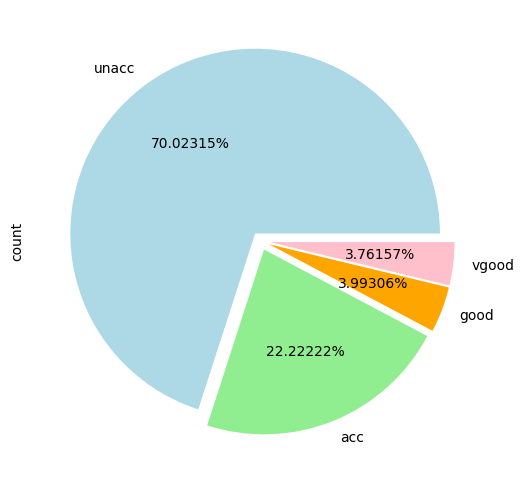

In [81]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind="pie", autopct="%0.05f%%",
                                   colors = ["lightblue", "lightgreen", "orange", "pink"],
                                   explode = (0.05, 0.05, 0.05, 0.05))

##### 데이터를 범주형 타입으로 변환

In [82]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety'] # 예제 데이터셋 컬럼 목록

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category') # astype() 메서드를 이용해 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values # 범주형 데이터를 숫자(넘파이 배열)로 변환하기 위해 cat.codes 사용
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1) # 두 개 이상의 넘파이 객체를 합침
categorical_data[:10] # 합친 넘파이 배열 중 열 개의 행을 출력

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

##### 배열을 텐서로 변환

In [83]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

##### 레이블로 사용할 컬럼을 텐서로 변환

In [84]:
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() # 1차원 텐서로 변환

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


##### 범주형 컬럼을 N차원으로 변환

In [85]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size + 1) // 2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


##### 데이터셋 분리

In [86]:
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]

train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

##### 데이터셋 분리 확인

In [87]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


##### 모델의 네트워크 생성

In [88]:
class Model(nn.Module):
    def __init__(self, embedding_size, output_size, layers, p=0.4):
        super().__init__()
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        self.embedding_dropout = nn.Dropout(p)

        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols # 입력층의 크기를 찾기 위해 범주형 컬럼 개수를 input_size에 저장

        for i in layers:
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i

        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers)

    def forward(self, x_categorical):
        embeddings = []
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))
        x = torch.cat(embeddings, 1)
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

##### Model 클래스의 객체 생성

In [89]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


##### 모델의 파라미터 정의

In [90]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##### CPU/GPU 사용 지정

In [91]:
device = "cuda" if torch.cuda.is_available() else "cpu"

##### 모델 학습

In [92]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss) # 반복할 때마다 오차를 aggregated_loss에 추가

    if i % 25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward() # 가중치를 업데이트하기 위해 손실 함수의 backward() 메서드 호출
    optimizer.step() # 옵티마이저 함수의 step() 메서드를 이용해 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}') # 오차가 25 에폭마다 출력

epoch:   1 loss: 1.70194256
epoch:  26 loss: 1.48730242
epoch:  51 loss: 1.40054297
epoch:  76 loss: 1.26769328
epoch: 101 loss: 1.13795531
epoch: 126 loss: 0.98553479
epoch: 151 loss: 0.86451918
epoch: 176 loss: 0.77545232
epoch: 201 loss: 0.73595273
epoch: 226 loss: 0.67875588
epoch: 251 loss: 0.64805800
epoch: 276 loss: 0.61907440
epoch: 301 loss: 0.61160982
epoch: 326 loss: 0.60682726
epoch: 351 loss: 0.60559601
epoch: 376 loss: 0.58781350
epoch: 401 loss: 0.59858996
epoch: 426 loss: 0.58411872
epoch: 451 loss: 0.58253002
epoch: 476 loss: 0.58220345
epoch: 500 loss: 0.5766654611


##### 테스트 데이터셋으로 모델 예측

In [93]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data).to(device)
    loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.57287979


##### 모델의 예측 확인

In [94]:
print(y_val[:5])

tensor([[ 2.8275,  1.4236, -4.5354, -4.0958],
        [ 1.6082,  0.8098, -2.1913, -2.0605],
        [ 2.0751,  1.0768, -2.9601, -2.6785],
        [ 2.9500,  1.6961, -4.2496, -4.2637],
        [ 3.9620,  2.1165, -4.4074, -3.9101]], device='cuda:0')


##### 가장 큰 값을 갖는 인덱스 확인

In [95]:
y_val = np.argmax(y_val.cpu().numpy(), axis=1)
print(y_val[:5])

[0 0 0 0 0]


##### 테스트 데이터셋을 이용한 정확도 확인

In [96]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

test_outputs=test_outputs.cpu().numpy()
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[258   1]
 [ 84   2]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.67      0.02      0.04        86

    accuracy                           0.75       345
   macro avg       0.71      0.51      0.45       345
weighted avg       0.73      0.75      0.66       345

0.7536231884057971
